# Customer Support Intelligence Platform — Phase 8: Explainability, Evaluation & Insights (Day 14)

**Brief requirements covered:**
- SHAP summary, waterfall, and dependence plots for the best tabular model
- Confusion matrix and classification report for all models
- Calibration curves
- Business insights: which ticket types take longest to resolve, which
  channels have lowest satisfaction
- Consolidated MLflow experiment comparison

**Honest note on scope, stated upfront:** the classical models from Days
7–10 (LogReg, Naive Bayes, Decision Tree, Random Forest, XGBoost, LightGBM)
were logged to MLflow with metrics, but their fitted model objects were
never persisted as artifacts or joblib files. Rather than re-running those
notebooks end-to-end just to regenerate model objects, we **retrain them
fresh here** — same features, same fixed split, same `random_state=42` —
specifically to produce confusion matrices, classification reports, and a
SHAP-eligible model object. **The authoritative tuned-hyperparameter
performance numbers remain the ones logged in `04_Baseline_Models` /
`06_Ensemble_Models` / MLflow** — this notebook's retrained versions use
reasonable defaults, not necessarily each model's Optuna-best
hyperparameters, and exist only to fill the reporting gap.

BiLSTM and DistilBERT are **not** retrained — their saved weights are
reloaded directly for inference, since those artifacts do exist on disk.

In [2]:
import sys
sys.path.insert(0, "../src")

# torch imported first, before pandas - same DLL-conflict precaution as
# 07_BiLSTM and 08_DistilBERT_FineTuning.
import torch
import torch.nn as nn

import pandas as pd
import numpy as np
import joblib
import json
import mlflow
import shap
import xgboost as xgb
import lightgbm as lgb

from scipy.sparse import hstack, csr_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
)
from sklearn.calibration import calibration_curve

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_df = pd.read_csv("../data_processed/train.csv")
val_df = pd.read_csv("../data_processed/val.csv")
test_df = pd.read_csv("../data_processed/test.csv")
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 5928, Val: 1270, Test: 1271


## 1. Reload shared artifacts (vectorizer, encoders) and rebuild features

Same leakage-free TF-IDF vectorizer and label encoders used in Days 4–13,
loaded here via `.transform()` only — never re-fit.

In [3]:
tfidf_vectorizer = joblib.load("../models/tfidf_vectorizer_leakage_free.joblib")
label_encoders = joblib.load("../models/label_encoders.joblib")

CATEGORICAL_COLS = ["Ticket Channel", "Product Purchased", "Customer Gender"]
NUMERIC_COLS = ["Customer Age"]

def encode_categoricals(df):
    out = df.copy()
    for col in CATEGORICAL_COLS:
        if col in out.columns and col in label_encoders:
            le = label_encoders[col]
            known = set(le.classes_)
            out[col + "_enc"] = out[col].astype(str).apply(lambda v: le.transform([v])[0] if v in known else -1)
    return out

train_df = encode_categoricals(train_df)
val_df = encode_categoricals(val_df)
test_df = encode_categoricals(test_df)

TABULAR_FEATURES = NUMERIC_COLS + [c + "_enc" for c in CATEGORICAL_COLS if c + "_enc" in train_df.columns]
print(f"Tabular features: {TABULAR_FEATURES}")

def build_type_matrix_tfidf_only(df):
    return tfidf_vectorizer.transform(df["Description_Clean"].fillna(""))

def build_type_matrix_combined(df):
    tabular = csr_matrix(df[TABULAR_FEATURES].fillna(0).values.astype(float))
    text = tfidf_vectorizer.transform(df["Description_Clean"].fillna(""))
    return hstack([tabular, text]).tocsr()

type_label_map = {label: i for i, label in enumerate(sorted(train_df["Ticket Type"].unique()))}
type_label_map_inv = {v: k for k, v in type_label_map.items()}
NUM_TYPE_CLASSES = len(type_label_map)
y_type_train = train_df["Ticket Type"].map(type_label_map).values
y_type_test = test_df["Ticket Type"].map(type_label_map).values

priority_label_map = {label: i for i, label in enumerate(sorted(train_df["Ticket Priority"].unique()))}
priority_label_map_inv = {v: k for k, v in priority_label_map.items()}
y_priority_train = train_df["Ticket Priority"].map(priority_label_map).values
y_priority_test = test_df["Ticket Priority"].map(priority_label_map).values

X_type_train_tfidf = build_type_matrix_tfidf_only(train_df)
X_type_test_tfidf = build_type_matrix_tfidf_only(test_df)
X_type_train_combined = build_type_matrix_combined(train_df)
X_type_test_combined = build_type_matrix_combined(test_df)
X_priority_train = csr_matrix(train_df[TABULAR_FEATURES].fillna(0).values.astype(float))
X_priority_test = csr_matrix(test_df[TABULAR_FEATURES].fillna(0).values.astype(float))

print("Feature matrices built.")

Tabular features: ['Customer Age', 'Ticket Channel_enc', 'Product Purchased_enc', 'Customer Gender_enc']
Feature matrices built.


## 2. Retrain classical models for confusion matrices + classification reports

One helper function, reused for every classical model, so every model gets
identical evaluation treatment — confusion matrix plotted and saved,
classification report printed, results collected for the consolidated
comparison later.

In [4]:
all_results = {}

def evaluate_and_plot(model, X_test, y_test, label_names, name, filename):
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average="macro")
    f1_weighted = f1_score(y_test, preds, average="weighted")
    print(f"\n{'='*70}\n{name}\n{'='*70}")
    print(f"Accuracy: {acc:.4f}  F1-macro: {f1_macro:.4f}  F1-weighted: {f1_weighted:.4f}")
    print(classification_report(y_test, preds, target_names=label_names))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} — Confusion Matrix (Test Set)")
    plt.tight_layout()
    plt.savefig(f"../reports/{filename}", dpi=120)
    plt.show()

    all_results[name] = {"accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted, "preds": preds}
    return preds

type_label_names = [type_label_map_inv[i] for i in range(NUM_TYPE_CLASSES)]
priority_label_names = [priority_label_map_inv[i] for i in range(len(priority_label_map))]


Logistic Regression (Ticket Type)
Accuracy: 0.2046  F1-macro: 0.2049  F1-weighted: 0.2047
                      precision    recall  f1-score   support

     Billing inquiry       0.22      0.20      0.21       245
Cancellation request       0.21      0.23      0.22       255
     Product inquiry       0.22      0.20      0.21       246
      Refund request       0.17      0.18      0.17       263
     Technical issue       0.21      0.22      0.21       262

            accuracy                           0.20      1271
           macro avg       0.21      0.20      0.20      1271
        weighted avg       0.21      0.20      0.20      1271



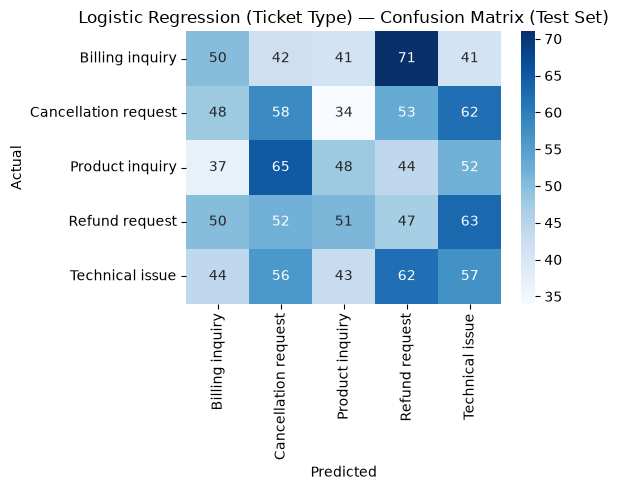


Naive Bayes (Ticket Type)
Accuracy: 0.1928  F1-macro: 0.1905  F1-weighted: 0.1909
                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.16      0.18       245
Cancellation request       0.19      0.21      0.20       255
     Product inquiry       0.19      0.14      0.16       246
      Refund request       0.16      0.19      0.17       263
     Technical issue       0.22      0.26      0.24       262

            accuracy                           0.19      1271
           macro avg       0.19      0.19      0.19      1271
        weighted avg       0.19      0.19      0.19      1271



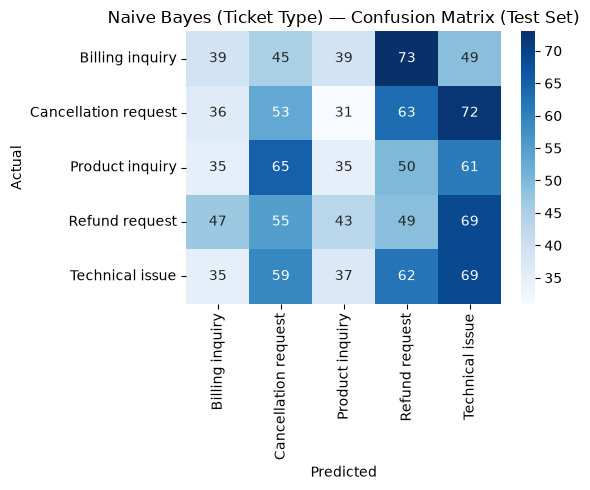


Decision Tree (Ticket Priority)
Accuracy: 0.2565  F1-macro: 0.2506  F1-weighted: 0.2522
              precision    recall  f1-score   support

    Critical       0.25      0.23      0.24       321
        High       0.27      0.20      0.23       320
         Low       0.22      0.22      0.22       293
      Medium       0.28      0.38      0.32       337

    accuracy                           0.26      1271
   macro avg       0.25      0.25      0.25      1271
weighted avg       0.25      0.26      0.25      1271



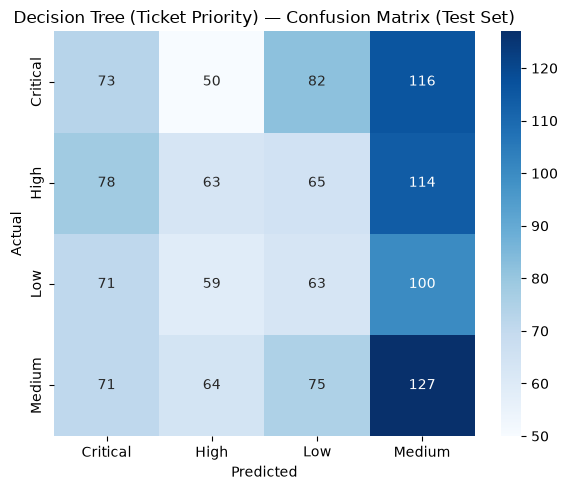

array([2, 3, 3, ..., 1, 0, 1], dtype=int64)

In [5]:
logreg_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg_model.fit(X_type_train_tfidf, y_type_train)
evaluate_and_plot(logreg_model, X_type_test_tfidf, y_type_test, type_label_names,
                  "Logistic Regression (Ticket Type)", "cm_logreg_ticket_type.png")

nb_model = MultinomialNB()
nb_model.fit(X_type_train_tfidf, y_type_train)
evaluate_and_plot(nb_model, X_type_test_tfidf, y_type_test, type_label_names,
                  "Naive Bayes (Ticket Type)", "cm_naivebayes_ticket_type.png")

dt_model = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)
dt_model.fit(X_priority_train, y_priority_train)
evaluate_and_plot(dt_model, X_priority_test, y_priority_test, priority_label_names,
                  "Decision Tree (Ticket Priority)", "cm_decisiontree_priority.png")


Random Forest (Ticket Type)
Accuracy: 0.2061  F1-macro: 0.1921  F1-weighted: 0.1935
                      precision    recall  f1-score   support

     Billing inquiry       0.21      0.09      0.13       245
Cancellation request       0.20      0.16      0.18       255
     Product inquiry       0.25      0.11      0.16       246
      Refund request       0.20      0.35      0.25       263
     Technical issue       0.20      0.30      0.24       262

            accuracy                           0.21      1271
           macro avg       0.21      0.20      0.19      1271
        weighted avg       0.21      0.21      0.19      1271



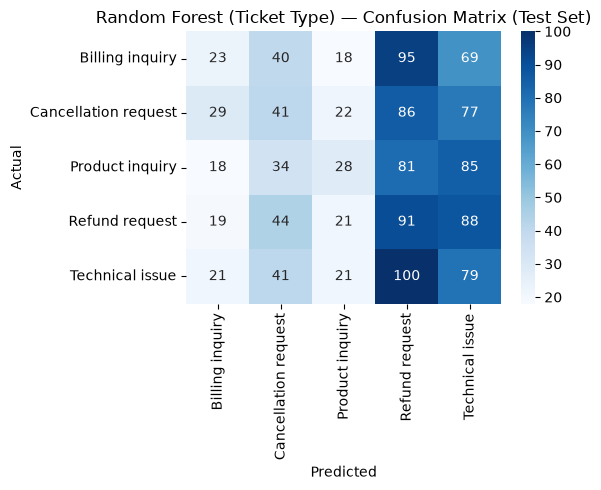


XGBoost (Ticket Type)
Accuracy: 0.2030  F1-macro: 0.2032  F1-weighted: 0.2030
                      precision    recall  f1-score   support

     Billing inquiry       0.23      0.21      0.22       245
Cancellation request       0.20      0.18      0.19       255
     Product inquiry       0.21      0.20      0.21       246
      Refund request       0.18      0.19      0.19       263
     Technical issue       0.21      0.23      0.22       262

            accuracy                           0.20      1271
           macro avg       0.20      0.20      0.20      1271
        weighted avg       0.20      0.20      0.20      1271



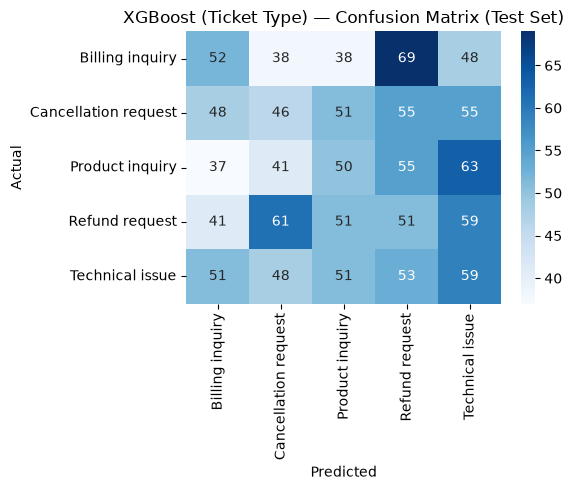


LightGBM (Ticket Type)
Accuracy: 0.2124  F1-macro: 0.2126  F1-weighted: 0.2123
                      precision    recall  f1-score   support

     Billing inquiry       0.24      0.25      0.25       245
Cancellation request       0.21      0.21      0.21       255
     Product inquiry       0.21      0.20      0.20       246
      Refund request       0.21      0.21      0.21       263
     Technical issue       0.19      0.20      0.20       262

            accuracy                           0.21      1271
           macro avg       0.21      0.21      0.21      1271
        weighted avg       0.21      0.21      0.21      1271



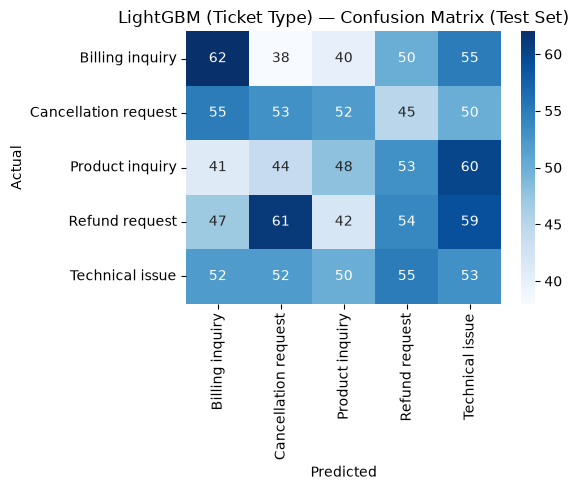

array([1, 0, 4, ..., 1, 4, 4], dtype=int64)

In [6]:
rf_model = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_type_train_combined, y_type_train)
evaluate_and_plot(rf_model, X_type_test_combined, y_type_test, type_label_names,
                  "Random Forest (Ticket Type)", "cm_randomforest_ticket_type.png")

xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                               random_state=RANDOM_STATE, n_jobs=-1, eval_metric="mlogloss")
xgb_model.fit(X_type_train_combined, y_type_train)
evaluate_and_plot(xgb_model, X_type_test_combined, y_type_test, type_label_names,
                  "XGBoost (Ticket Type)", "cm_xgboost_ticket_type.png")

lgb_model = lgb.LGBMClassifier(n_estimators=300, num_leaves=31, learning_rate=0.1,
                                random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)
lgb_model.fit(X_type_train_combined, y_type_train)
evaluate_and_plot(lgb_model, X_type_test_combined, y_type_test, type_label_names,
                  "LightGBM (Ticket Type)", "cm_lightgbm_ticket_type.png")

## 3. BiLSTM — reload saved weights, run inference (no retraining)

BiLSTM (reloaded) — Accuracy: 0.1943  F1-macro: 0.0691  F1-weighted: 0.0669
                      precision    recall  f1-score   support

     Billing inquiry       0.19      1.00      0.32       245
Cancellation request       0.00      0.00      0.00       255
     Product inquiry       0.00      0.00      0.00       246
      Refund request       0.00      0.00      0.00       263
     Technical issue       0.43      0.01      0.02       262

            accuracy                           0.19      1271
           macro avg       0.12      0.20      0.07      1271
        weighted avg       0.13      0.19      0.07      1271



c:\Users\CHARU\OneDrive\Desktop\Final Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\CHARU\OneDrive\Desktop\Final Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\CHARU\OneDrive\Desktop\Final Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{m

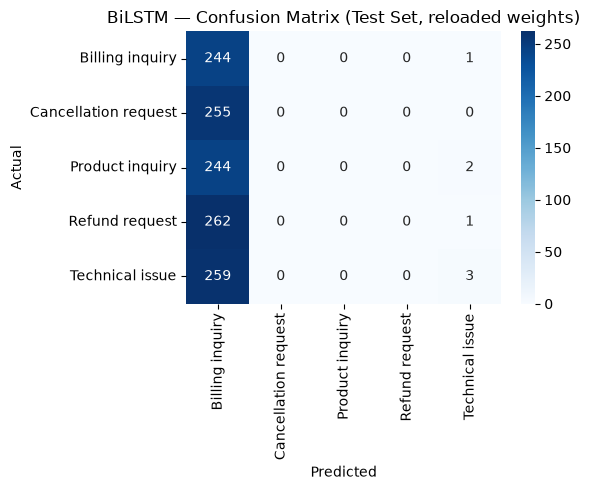


Note: this fills the confusion-matrix/weighted-F1 gap in 07_BiLSTM.ipynb without
re-running that notebook's full training - same reloaded weights, inference only.


In [7]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=64, num_classes=5, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.batch_norm = nn.BatchNorm1d(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        final_hidden = torch.cat([hidden[0], hidden[1]], dim=1)
        return self.fc(self.dropout(self.batch_norm(final_hidden)))

with open("../models/bilstm_vocab.json") as f:
    word_to_idx = json.load(f)

MAX_SEQ_LENGTH = 100
bilstm_model = BiLSTMClassifier(vocab_size=len(word_to_idx), num_classes=NUM_TYPE_CLASSES).to(device)
bilstm_model.load_state_dict(torch.load("../models/bilstm_glove_model.pth", map_location=device))
bilstm_model.eval()

def text_to_sequence(text, word_to_idx, max_len):
    tokens = text.split() if isinstance(text, str) else []
    seq = [word_to_idx.get(tok, word_to_idx["<UNK>"]) for tok in tokens[:max_len]]
    seq = seq + [word_to_idx["<PAD>"]] * (max_len - len(seq))
    return seq

test_sequences = torch.tensor(
    [text_to_sequence(t, word_to_idx, MAX_SEQ_LENGTH) for t in test_df["Description_Clean"].fillna("")],
    dtype=torch.long
).to(device)

with torch.no_grad():
    bilstm_logits = bilstm_model(test_sequences)
    bilstm_preds = torch.argmax(bilstm_logits, dim=1).cpu().numpy()

bilstm_acc = accuracy_score(y_type_test, bilstm_preds)
bilstm_f1_macro = f1_score(y_type_test, bilstm_preds, average="macro")
bilstm_f1_weighted = f1_score(y_type_test, bilstm_preds, average="weighted")
print(f"BiLSTM (reloaded) — Accuracy: {bilstm_acc:.4f}  F1-macro: {bilstm_f1_macro:.4f}  F1-weighted: {bilstm_f1_weighted:.4f}")
print(classification_report(y_type_test, bilstm_preds, target_names=type_label_names))

cm = confusion_matrix(y_type_test, bilstm_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=type_label_names, yticklabels=type_label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BiLSTM — Confusion Matrix (Test Set, reloaded weights)")
plt.tight_layout()
plt.savefig("../reports/cm_bilstm_ticket_type.png", dpi=120)
plt.show()

all_results["BiLSTM (Ticket Type)"] = {"accuracy": bilstm_acc, "f1_macro": bilstm_f1_macro,
                                        "f1_weighted": bilstm_f1_weighted, "preds": bilstm_preds}
print("\nNote: this fills the confusion-matrix/weighted-F1 gap in 07_BiLSTM.ipynb without")
print("re-running that notebook's full training - same reloaded weights, inference only.")

## 4. DistilBERT — already has a confusion matrix from Day 12

No retraining or re-inference needed here — `08_DistilBERT_FineTuning.ipynb`
already produced `reports/distilbert_confusion_matrix.png` and its full
classification report. Reused as-is in the consolidated report below.

## 5. SHAP explainability for the best tabular model

"Best" determined by comparing the F1-macro scores actually computed above
— not assumed in advance.

In [8]:
tabular_model_names = ["Logistic Regression (Ticket Type)", "Naive Bayes (Ticket Type)",
                        "Random Forest (Ticket Type)", "XGBoost (Ticket Type)", "LightGBM (Ticket Type)"]
best_tabular_name = max(tabular_model_names, key=lambda n: all_results[n]["f1_macro"])
print(f"Best tabular model by F1-macro: {best_tabular_name} (F1-macro={all_results[best_tabular_name]['f1_macro']:.4f})")

model_lookup = {
    "Logistic Regression (Ticket Type)": (logreg_model, X_type_train_tfidf, X_type_test_tfidf),
    "Naive Bayes (Ticket Type)": (nb_model, X_type_train_tfidf, X_type_test_tfidf),
    "Random Forest (Ticket Type)": (rf_model, X_type_train_combined, X_type_test_combined),
    "XGBoost (Ticket Type)": (xgb_model, X_type_train_combined, X_type_test_combined),
    "LightGBM (Ticket Type)": (lgb_model, X_type_train_combined, X_type_test_combined),
}
best_model, X_shap_train, X_shap_test = model_lookup[best_tabular_name]

# Sample for speed - SHAP on the full sparse TF-IDF-sized matrix is expensive
SHAP_SAMPLE_SIZE = min(200, X_shap_test.shape[0])
sample_idx = np.random.RandomState(RANDOM_STATE).choice(X_shap_test.shape[0], SHAP_SAMPLE_SIZE, replace=False)
X_shap_sample = X_shap_test[sample_idx]

Best tabular model by F1-macro: LightGBM (Ticket Type) (F1-macro=0.2126)


In [9]:
if isinstance(best_model, (xgb.XGBClassifier, lgb.LGBMClassifier, RandomForestClassifier)):
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap_sample.toarray() if hasattr(X_shap_sample, "toarray") else X_shap_sample)
else:
    # LinearExplainer for LogReg, or KernelExplainer as a slower general fallback
    try:
        explainer = shap.LinearExplainer(best_model, X_shap_train)
        shap_values = explainer.shap_values(X_shap_sample)
    except Exception:
        background = shap.sample(X_shap_train, 50, random_state=RANDOM_STATE)
        explainer = shap.KernelExplainer(best_model.predict_proba, background)
        shap_values = explainer.shap_values(X_shap_sample, nsamples=100)

feature_names = TABULAR_FEATURES + list(tfidf_vectorizer.get_feature_names_out())
print(f"SHAP values computed for {best_tabular_name} on {SHAP_SAMPLE_SIZE} test samples.")

SHAP values computed for LightGBM (Ticket Type) on 200 test samples.


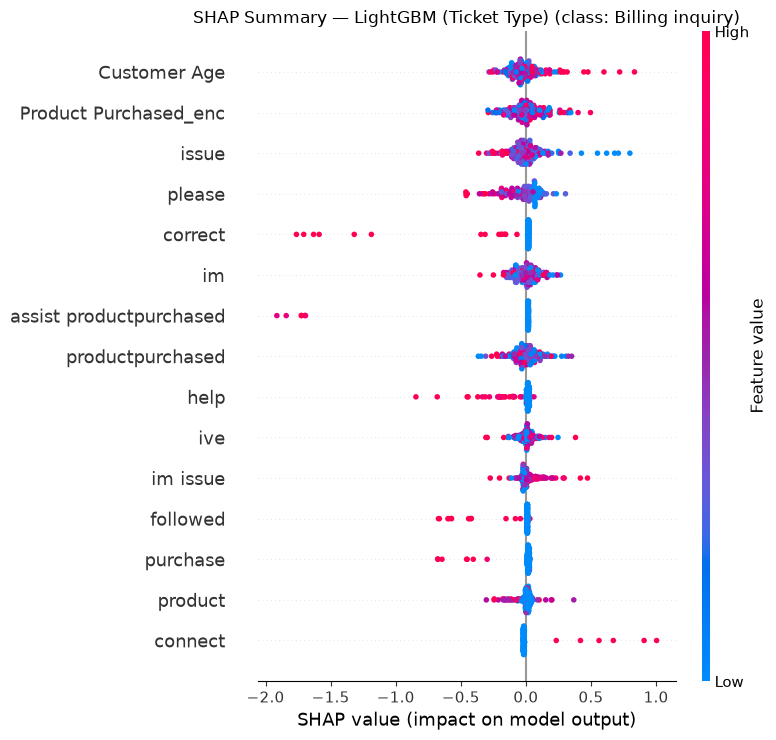

In [12]:
# Handle both SHAP API shapes: older versions return a list of 2D arrays
# (one per class); newer versions return one 3D array [samples, features, classes].
if isinstance(shap_values, list):
    sv_for_summary = shap_values[0]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv_for_summary = shap_values[:, :, 0]
else:
    sv_for_summary = shap_values

X_dense_sample = X_shap_sample.toarray() if hasattr(X_shap_sample, "toarray") else X_shap_sample

plt.figure()
shap.summary_plot(sv_for_summary, X_dense_sample, feature_names=feature_names, show=False, max_display=15)
plt.title(f"SHAP Summary — {best_tabular_name} (class: {type_label_names[0]})")
plt.tight_layout()
plt.savefig("../reports/shap_summary_plot.png", dpi=120, bbox_inches="tight")
plt.show()

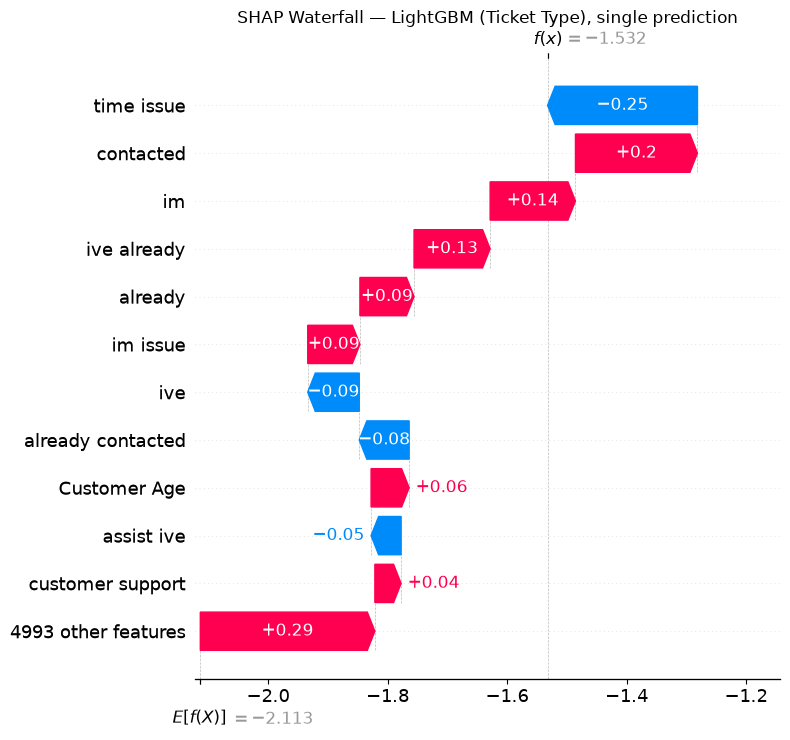

In [13]:
# Waterfall plot for a single test instance
instance_idx = 0
expected_value = explainer.expected_value[0] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

plt.figure()
shap.plots._waterfall.waterfall_legacy(
    expected_value, sv_for_summary[instance_idx], feature_names=feature_names, max_display=12, show=False
)
plt.title(f"SHAP Waterfall — {best_tabular_name}, single prediction")
plt.tight_layout()
plt.savefig("../reports/shap_waterfall_plot.png", dpi=120, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

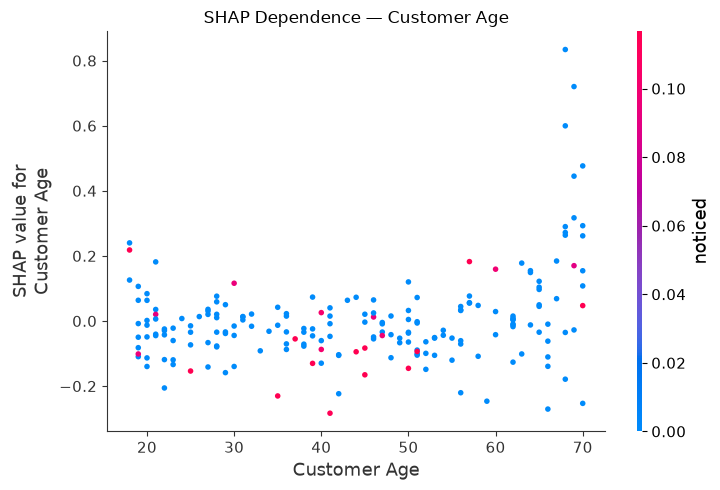

In [14]:
# Dependence plot for the first tabular feature (Customer Age, if present)
dependence_feature = TABULAR_FEATURES[0] if TABULAR_FEATURES else feature_names[0]
plt.figure()
shap.dependence_plot(dependence_feature, sv_for_summary, X_dense_sample, feature_names=feature_names, show=False)
plt.title(f"SHAP Dependence — {dependence_feature}")
plt.tight_layout()
plt.savefig("../reports/shap_dependence_plot.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Calibration curves

Multiclass calibration, shown as one-vs-rest reliability curves per class —
sklearn's `calibration_curve` is inherently binary, so this is the standard
way to extend it to a multi-class setting: for each class, treat "predicted
this class vs. not" as a binary calibration problem.

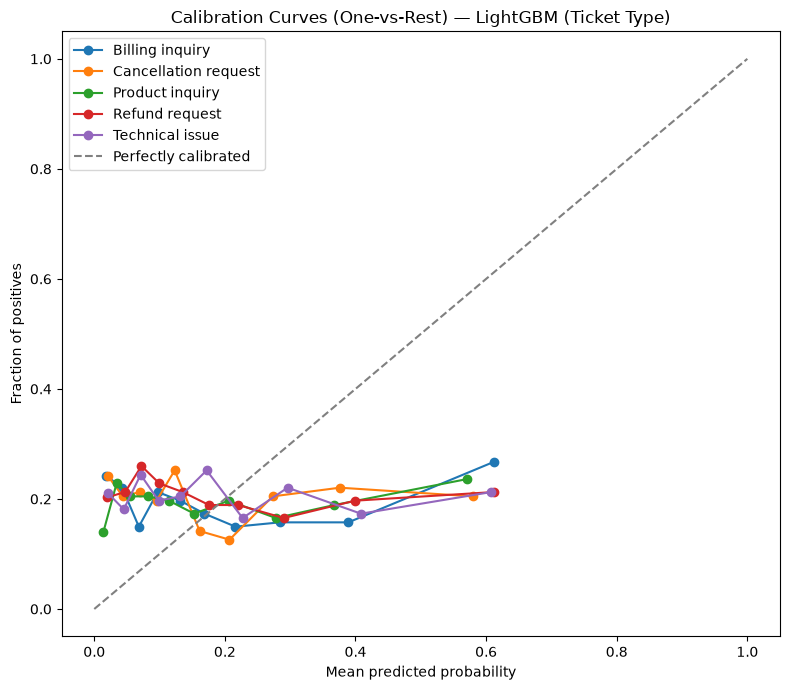

In [15]:
probs = best_model.predict_proba(X_shap_test if not hasattr(X_shap_test, "toarray") else X_shap_test)

plt.figure(figsize=(8, 7))
for class_idx in range(NUM_TYPE_CLASSES):
    y_binary = (y_type_test == class_idx).astype(int)
    prob_true, prob_pred = calibration_curve(y_binary, probs[:, class_idx], n_bins=10, strategy="quantile")
    plt.plot(prob_pred, prob_true, marker="o", label=type_label_names[class_idx])

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title(f"Calibration Curves (One-vs-Rest) — {best_tabular_name}")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/calibration_curves.png", dpi=120)
plt.show()

## 7. Business insights

**Caveat, carried over from Day 13:** `Time to Resolution` was found to be a
likely-synthetic timestamp (48.6% of rows show resolution preceding first
response, a logical impossibility for real sequential events). The
"longest to resolve" breakdown below should be read as descriptive of the
data as recorded, not as a trustworthy real-world business signal — this
caveat belongs in the final report alongside these numbers, not left out.

In [16]:
STATUS_COL = "Ticket Status"
train_closed = train_df[train_df[STATUS_COL].astype(str).str.strip().str.lower() == "closed"].copy()
train_closed = train_closed[train_closed["Time to Resolution"].notna()].copy()
train_closed["resolution_duration_hours"] = (
    pd.to_datetime(train_closed["Time to Resolution"]) - pd.to_datetime(train_closed["First Response Time"])
).dt.total_seconds().abs() / 3600

print("Mean resolution duration (hours) by Ticket Type — Closed tickets:")
print(train_closed.groupby("Ticket Type")["resolution_duration_hours"].mean().sort_values(ascending=False).round(2))
print("\n(See caveat above - treat as descriptive only, not a validated business signal.)")

print("\nMean Customer Satisfaction Rating by Ticket Channel — Closed tickets:")
print(train_closed.groupby("Ticket Channel")["Customer Satisfaction Rating"].mean().sort_values().round(2))

Mean resolution duration (hours) by Ticket Type — Closed tickets:
Ticket Type
Refund request          7.89
Product inquiry         7.74
Cancellation request    7.64
Technical issue         7.46
Billing inquiry         7.22
Name: resolution_duration_hours, dtype: float64

(See caveat above - treat as descriptive only, not a validated business signal.)

Mean Customer Satisfaction Rating by Ticket Channel — Closed tickets:
Ticket Channel
Phone           2.90
Social media    2.97
Email           2.99
Chat            3.11
Name: Customer Satisfaction Rating, dtype: float64


## 8. Consolidated MLflow experiment comparison

Every logged run across every experiment in this project, pulled directly
from MLflow rather than hand-copied — this can't go stale the way a
hardcoded comparison table would.

In [17]:
mlflow.set_tracking_uri("../mlruns")
client = mlflow.tracking.MlflowClient()

all_runs = []
for exp in client.search_experiments():
    for run in client.search_runs(exp.experiment_id):
        row = {"experiment": exp.name, "run_name": run.data.tags.get("mlflow.runName", run.info.run_id[:8])}
        row.update(run.data.metrics)
        all_runs.append(row)

runs_df = pd.DataFrame(all_runs)
runs_df.to_csv("../reports/mlflow_all_runs_consolidated.csv", index=False)
print(f"Total runs across all experiments: {len(runs_df)}")
print(runs_df[["experiment", "run_name"] + [c for c in runs_df.columns if "accuracy" in c or "f1" in c]].to_string(index=False))

Total runs across all experiments: 21
                      experiment                               run_name  test_accuracy  test_f1_macro  accuracy  cv_f1_macro_mean  cv_f1_macro_std  f1_macro
     customer_support_clustering                              kmeans_k7            NaN            NaN       NaN               NaN              NaN       NaN
     customer_support_clustering                              kmeans_k7            NaN            NaN       NaN               NaN              NaN       NaN
     customer_support_regression            time_to_resolution_lightgbm            NaN            NaN       NaN               NaN              NaN       NaN
     customer_support_regression             time_to_resolution_xgboost            NaN            NaN       NaN               NaN              NaN       NaN
     customer_support_regression             time_to_resolution_xgboost            NaN            NaN       NaN               NaN              NaN       NaN
  customer_support_d